# Lab 8: Edge Detection and Feature Extraction

## Theory

### Edge Detection
Edges represent significant intensity changes.

---

### Gradient Operators
- Sobel, Prewitt → detect edges using first derivatives
- Scharr → improved version of Sobel

---

### Second Order Operators
- LoG → detects zero-crossings
- DoG → approximation of LoG

---

### Canny Edge Detector
Steps:
1. Noise reduction
2. Gradient computation
3. Non-maximum suppression
4. Hysteresis thresholding

---

### Hough Transform
Detects lines by mapping image points to parameter space.

---

### HOG
Extracts gradient orientation features, useful for object detection.

# Experiment 1: Edge Detection

## Problem
To detect edges using various operators.

## Theory
Edge detection identifies intensity changes in images.
Different operators detect edges in different ways.

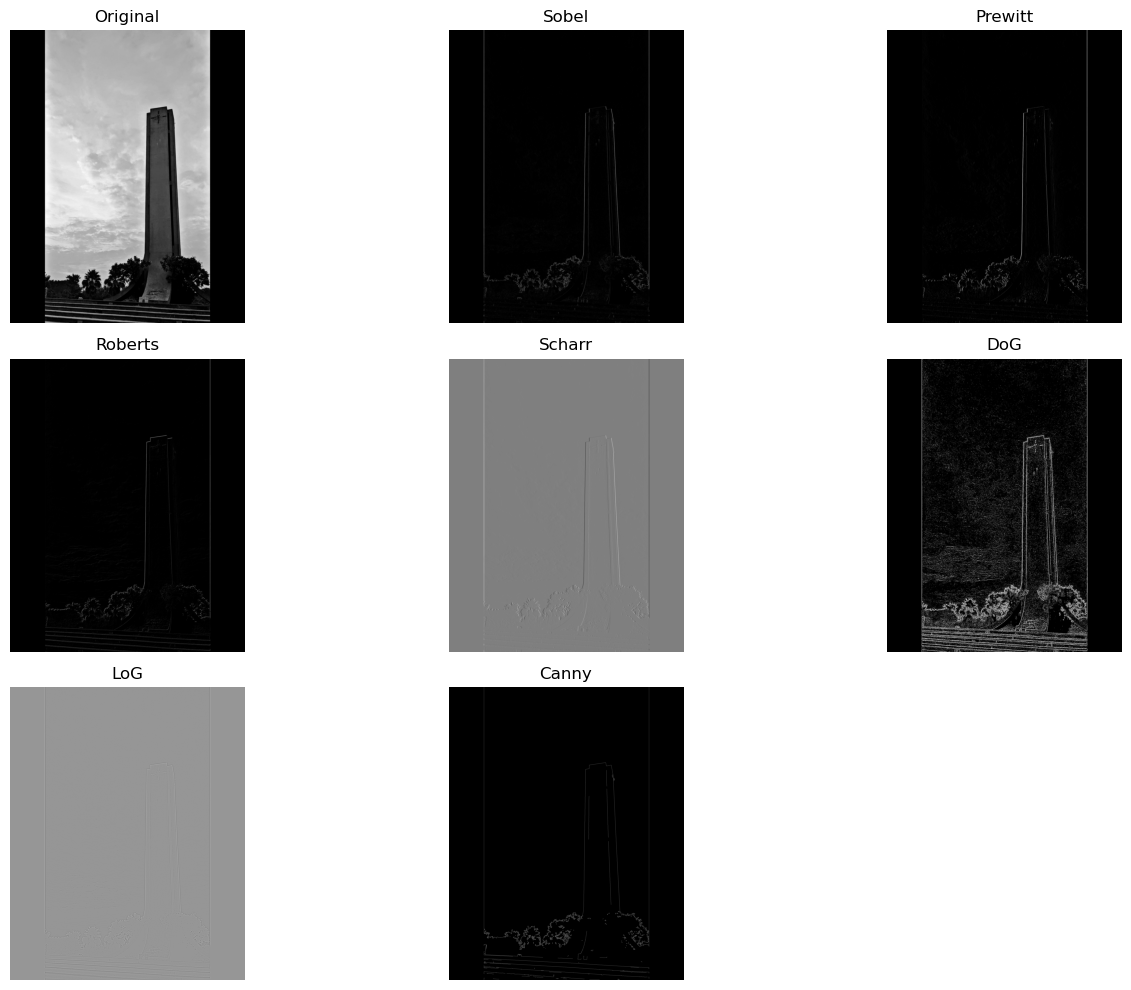

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

# Sobel
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
sobel = np.abs(sobelx)

# Prewitt
kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitt = cv2.filter2D(img, -1, kernelx)

# Roberts
kernel_roberts = np.array([[1,0],[0,-1]])
roberts = cv2.filter2D(img, -1, kernel_roberts)

# Scharr
scharr = cv2.Scharr(img, cv2.CV_64F, 1, 0)

# DoG
blur1 = cv2.GaussianBlur(img, (5,5), 1)
blur2 = cv2.GaussianBlur(img, (5,5), 2)
dog = blur1 - blur2

# LoG
log = cv2.Laplacian(cv2.GaussianBlur(img, (5,5), 0), cv2.CV_64F)

# Canny
canny = cv2.Canny(img, 100, 200)

# Display
titles = ["Original","Sobel","Prewitt","Roberts","Scharr","DoG","LoG","Canny"]
images = [img,sobel,prewitt,roberts,scharr,dog,log,canny]

plt.figure(figsize=(14,10))
for i in range(8):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Experiment 2: Line Detection

## Problem
To detect lines in an image.

## Theory
Hough Transform detects lines by mapping points to parameter space.

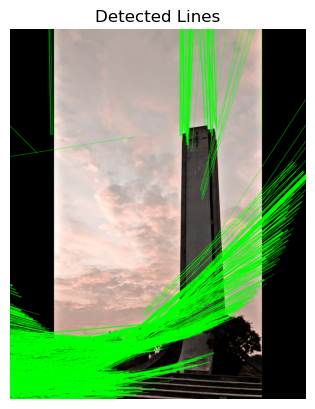

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLines(edges, 1, np.pi/180, 100)

if lines is not None:
    for rho, theta in lines[:,0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*rho
        y0 = b*rho

        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))

        cv2.line(img, (x1,y1), (x2,y2), (0,255,0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Detected Lines")
plt.axis('off')
plt.show()

# Experiment 3: HOG Visualization

## Problem
To visualize Histogram of Oriented Gradients.

## Theory
HOG captures edge directions and is useful for object detection.

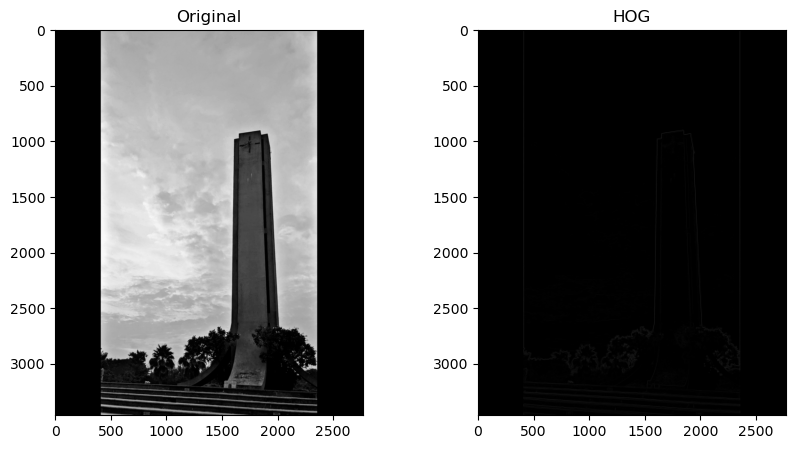

In [41]:
from skimage.feature import hog
from skimage import exposure
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

fd, hog_image = hog(img, visualize=True)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG")

plt.show()

# Experiment 4: People Detection using HOG

## Problem
To detect humans in an image using HOG descriptor.

## Theory
HOG + SVM is used for pedestrian detection.

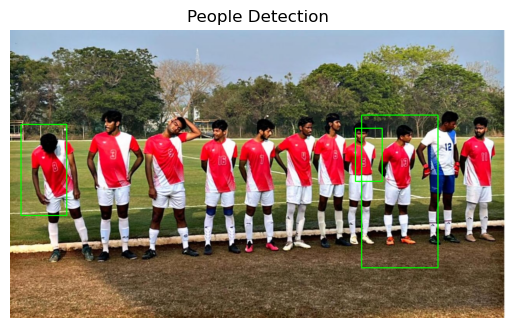

In [43]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('people.jpg')

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

boxes, _ = hog.detectMultiScale(img)

for (x, y, w, h) in boxes:
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("People Detection")
plt.axis('off')
plt.show()

# interpretation
Edge detection techniques highlight boundaries in images using intensity gradients. HOG captures gradient orientations for object detection. Hough Transform detects lines effectively. HOG-based methods can be used for human detection.
plt.axis('off')
plt.show()